# Linear Regression Practical Tasks
This notebook implements baseline linear regression models, feature count comparisons, split ratio effects, and evaluation metric sensitivity analyses on the California housing dataset.


## Data Loading


In [25]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [26]:
df = pd.read_csv(r"housing.csv")


In [27]:
df.shape


(20640, 10)

In [28]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [29]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())


## Task 1: Build a baseline linear regression model


In [30]:
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X = df[features]
y = df['median_house_value']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(X_test)


In [34]:
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)


In [35]:
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")


MSE: 5059928371.165384
RMSE: 71133.17349286044
MAE: 51810.48362804233
R2: 0.6138664756435155


In [36]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df.head(10)


,Actual,Predicted
20046,47700.0,63736.591338
3024,45800.0,154344.594319
15663,500001.0,253073.194287
20484,218600.0,263507.746536
9814,278000.0,266883.359611
13311,158700.0,155403.494466
7113,198200.0,287058.654200
7668,157500.0,223660.781552
18246,340000.0,257045.027183
5723,446600.0,404273.366113


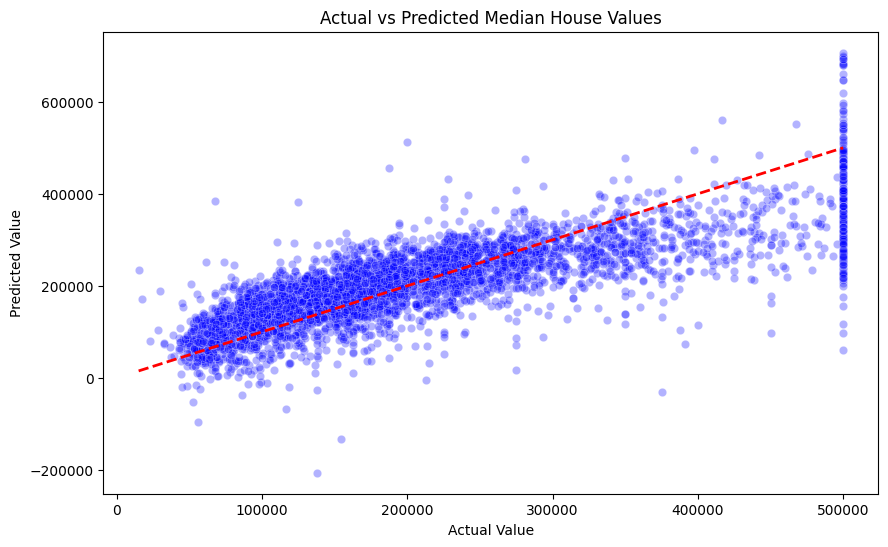

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Median House Values')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.show()


## Task 2: Compare one-feature and multi-feature models


In [38]:
X_train_a = X_train[['median_income']]
X_test_a = X_test[['median_income']]


In [39]:
model_a = LinearRegression()
model_a.fit(X_train_a, y_train)
y_pred_a = model_a.predict(X_test_a)


In [40]:
X_train_b = X_train[['median_income', 'housing_median_age', 'total_rooms']]
X_test_b = X_test[['median_income', 'housing_median_age', 'total_rooms']]


In [41]:
model_b = LinearRegression()
model_b.fit(X_train_b, y_train)
y_pred_b = model_b.predict(X_test_b)


In [42]:
metrics_a = {
    'MSE': metrics.mean_squared_error(y_test, y_pred_a),
    'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_a)),
    'MAE': metrics.mean_absolute_error(y_test, y_pred_a),
    'R2': metrics.r2_score(y_test, y_pred_a)
}


In [43]:
metrics_b = {
    'MSE': metrics.mean_squared_error(y_test, y_pred_b),
    'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_b)),
    'MAE': metrics.mean_absolute_error(y_test, y_pred_b),
    'R2': metrics.r2_score(y_test, y_pred_b)
}


In [44]:
compare_df = pd.DataFrame([metrics_a, metrics_b], index=['Model A (1 Feature)', 'Model B (3 Features)'])
compare_df


,MSE,RMSE,MAE,R2
Model A (1 Feature),7.091158e+09,84209.012414,62990.865301,0.458859
Model B (3 Features),6.563179e+09,81013.447402,60348.037530,0.499150


Model B performed better than Model A because it has lower errors (MSE, RMSE, and MAE) and a higher R-squared score, showing that including more features helps the model capture more variance in housing values.


## Task 3: Test different train/test splits


In [45]:
splits = [0.2, 0.3, 0.4]
split_names = ['80/20', '70/30', '60/40']
split_results = []


In [46]:
for test_sz, name in zip(splits, split_names):
    X_tr, X_te, y_tr, y_te = train_test_split(X[['median_income', 'housing_median_age', 'total_rooms']], y, test_size=test_sz, random_state=42)
    
    m = LinearRegression()
    m.fit(X_tr, y_tr)
    
    pred_tr = m.predict(X_tr)
    pred_te = m.predict(X_te)
    
    split_results.append({
        'Split': name,
        'Train MSE': metrics.mean_squared_error(y_tr, pred_tr),
        'Test MSE': metrics.mean_squared_error(y_te, pred_te),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_tr, pred_tr)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_te, pred_te)),
        'Train MAE': metrics.mean_absolute_error(y_tr, pred_tr),
        'Test MAE': metrics.mean_absolute_error(y_te, pred_te),
        'Train R2': metrics.r2_score(y_tr, pred_tr),
        'Test R2': metrics.r2_score(y_te, pred_te)
    })


In [47]:
splits_df = pd.DataFrame(split_results)
splits_df


,Split,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,80/20,6.453767e+09,6.563179e+09,80335.343096,81013.447402,59986.955235,60348.03753,0.517215,0.499150
1,70/30,6.508335e+09,6.399531e+09,80674.254555,79997.069821,60192.064911,59802.84232,0.514193,0.512432
2,60/40,6.433879e+09,6.538701e+09,80211.466331,80862.235104,59786.839371,60354.79748,0.515051,0.511565


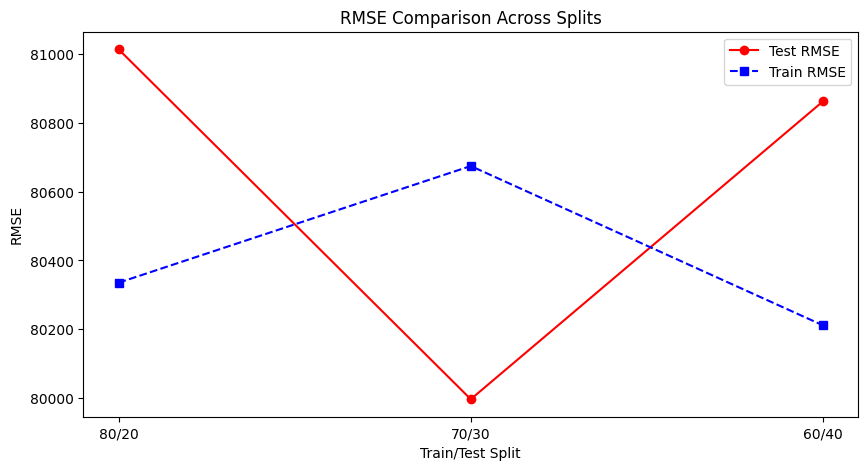

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(splits_df['Split'], splits_df['Test RMSE'], marker='o', label='Test RMSE', color='red')
plt.plot(splits_df['Split'], splits_df['Train RMSE'], marker='s', linestyle='--', label='Train RMSE', color='blue')
plt.title('RMSE Comparison Across Splits')
plt.xlabel('Train/Test Split')
plt.ylabel('RMSE')
plt.legend()
plt.show()


The 80/20 split gives the most reliable and stable performance, as it yields the lowest test error metrics (RMSE/MSE) while keeping a very small gap between the training and testing sets.


## Task 4: Metric verification and exploration


In [49]:
y_actual = y_test.values
y_predicted = y_pred_b.copy()


In [50]:
manual_mse = np.mean((y_actual - y_predicted) ** 2)
manual_rmse = np.sqrt(manual_mse)
manual_mae = np.mean(np.abs(y_actual - y_predicted))
manual_r2 = 1 - (np.sum((y_actual - y_predicted) ** 2) / np.sum((y_actual - np.mean(y_actual)) ** 2))


In [51]:
med_ae = metrics.median_absolute_error(y_test, y_predicted)


In [52]:
metrics_summary = pd.DataFrame({
    'Sklearn': [metrics_b['MSE'], metrics_b['RMSE'], metrics_b['MAE'], metrics_b['R2'], med_ae],
    'Manual': [manual_mse, manual_rmse, manual_mae, manual_r2, np.median(np.abs(y_actual - y_predicted))]
}, index=['MSE', 'RMSE', 'MAE', 'R2', 'Median AE'])
metrics_summary


,Sklearn,Manual
MSE,6.563179e+09,6.563179e+09
RMSE,8.101345e+04,8.101345e+04
MAE,6.034804e+04,6.034804e+04
R2,4.991504e-01,4.991504e-01
Median AE,4.839961e+04,4.839961e+04


In [53]:
y_pred_outliers = y_predicted.copy()
y_pred_outliers[0] += 1000000
y_pred_outliers[1] += 1000000
y_pred_outliers[2] += 1000000


In [54]:
outlier_mse = metrics.mean_squared_error(y_test, y_pred_outliers)
outlier_rmse = np.sqrt(outlier_mse)
outlier_mae = metrics.mean_absolute_error(y_test, y_pred_outliers)


In [55]:
outlier_comparison = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE'],
    'Before Outliers': [metrics_b['MSE'], metrics_b['RMSE'], metrics_b['MAE']],
    'After Outliers': [outlier_mse, outlier_rmse, outlier_mae]
})
outlier_comparison['Percentage Increase (%)'] = ((outlier_comparison['After Outliers'] - outlier_comparison['Before Outliers']) / outlier_comparison['Before Outliers']) * 100
outlier_comparison


,Metric,Before Outliers,After Outliers,Percentage Increase (%)
0,MSE,6.563179e+09,7.242834e+09,10.355585
1,RMSE,8.101345e+04,8.510484e+04,5.050266
2,MAE,6.034804e+04,6.094925e+04,0.996236


MSE reacts most strongly to the large errors, showing the highest percentage increase. This is because MSE squares the errors, amplifying the impact of outliers compared to RMSE and MAE.
